In [ ]:
import pandas as pd
import seaborn as sns
from rich import print as printr
import matplotlib.pyplot as plt
from carps.analysis.utils import setup_seaborn, filter_only_final_performance
from dacboenv.experiment.analysis.utils import postprocess_bbob
from dacboenv.experiment.analysis.utils import RWBM, postprocess_benchmarks, create_yaml_string, sort_df_by_mean


def fix_benchmark_id(logs: pd.DataFrame) -> pd.DataFrame:
    def _fix_benchmark_id(row: pd.Series) -> str:
        if row["benchmark_id"] == "train":
            return row["benchmark_id"]
        if row["task_id"].startswith("bbob/2"):
            return "BBOB-2d"
        if row["task_id"].startswith("bbob/8"):
            return "BBOB-8d"
        if row["task_id"].startswith("yahpo"):
            return "YAHPO"
        if row["task_id"].startswith("bnnbo"):
            return "nasengb"
        if "Ackley" in row["task_id"] or "Hartmann" in row["task_id"] or "Schwefel" in row["task_id"] or "Levy" in row["task_id"]:
            return "OptBench"
        return row["benchmark_id"]
    # logs["benchmark_id"] = None
    logs["benchmark_id"] = logs.apply(_fix_benchmark_id, axis="columns")
    print(logs["benchmark_id"].unique())
    return logs

setup_seaborn()

train_instances = [
    "bbob/2/1/1",
    "bbob/2/8/1",
    "bbob/2/10/1",
    "bbob/2/17/1",
    "bbob/2/21/1",
    "yahpo/so/rbv2_glmnet/375/None",
]

df = pd.read_parquet("../runs_eval_nips/logs.parquet")
df_cfg = pd.read_parquet("../runs_eval_nips/logs_cfg.parquet")
df["optimizer_id"] = df["optimizer_id"].map(lambda x: x.replace("-MLP-Def--dacbo_Csymlogregret_AWEI-cont_Ssawei_Rsymlogregret-SAWEI-P_Ibbob2d_fid1_3seeds", ""))
df = postprocess_benchmarks(df, df_cfg)
df_train = df[df["task_id"].isin(train_instances)]
df_train["benchmark_id"] = "train"
df = pd.concat((df, df_train)).reset_index(drop=True)
df = fix_benchmark_id(df)


printr(df["benchmark_id"].unique())
df_final = filter_only_final_performance(df)

# Reduce PPO name
df_final_ppo = df_final[df_final["optimizer_id"].str.startswith("PPO")].copy()
df_final_ppo["outer_seed"] = df_final_ppo["optimizer_id"].map(lambda x: int(x.split("--")[-1].replace("seed", "")))
df_final_ppo["optimizer_id"] = df_final_ppo["optimizer_id"].map(lambda x: "--".join(x.split("--")[:-1]))

# Average over outer seeds
df_final_ppo_mean = df_final_ppo.groupby(["benchmark_id", "optimizer_id", "task_id", "seed"])["log_regret"].mean().reset_index().copy()
df_final_ppo_mean["optimizer_id"] = df_final_ppo_mean["optimizer_id"] + "--mean"

# Calculate VBS over outer seeds
df_final_ppo_vbs = df_final_ppo.groupby(["benchmark_id", "optimizer_id", "task_id", "seed"])["log_regret"].min().reset_index().copy()
df_final_ppo_vbs["optimizer_id"] = df_final_ppo_vbs["optimizer_id"] + "--vbs"

df_final = pd.concat([df_final, df_final_ppo_mean, df_final_ppo_vbs]).reset_index(drop=True)

printr(df_final["optimizer_id"].unique())

/bigwork/nhwpbenc/repos/dacboenv/dacboenv/experiment/analysis/utils.py:585: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data = data.groupby("task_id").apply(calc_fmax).reset_index(drop=True)
/bigwork/nhwpbenc/repos/dacboenv/.env/lib/python3.13/site-packages/pandas/core/algorithms.py:1743: RuntimeWarning: divide by zero encountered in log
  return lib.map_infer(values, mapper, convert=convert)
/bigwork/nhwpbenc/repos/dacboenv/dacboenv/experiment/analysis/utils.py:443: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclu

Processing BBOB...
Processing YAHPO...


100%|██████████| 20/20 [00:00<00:00, 27.81it/s]
/bigwork/nhwpbenc/repos/dacboenv/dacboenv/experiment/analysis/utils.py:309: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data = data.groupby("task_id").apply(calc_fmin).reset_index(drop=True)
/bigwork/nhwpbenc/repos/dacboenv/dacboenv/experiment/analysis/utils.py:586: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return data.groupby("benchmark_id").apply(_postprocess).r

['BBOB-2d' 'BBOB-8d' 'YAHPO' 'train']


['BBOB-2d' 'BBOB-8d' 'YAHPO' 'train']

['DefaultPolicy' 'PPO_i1--seed4' 'PPO_i10--seed3' 'PPO_i1--seed2'
 'PPO_i10--seed5' 'SAWEI-P' 'PPO_i5--seed2' 'PPO_i1--seed5' 'Random'
 'PPO_i5--seed1' 'PPO_i5--seed5' 'PPO_i1--seed3' 'PPO_i10--seed1'
 'PPO_i10--seed2' 'PPO_i5--seed4' 'PPO_i10--seed4' 'PPO_i1--seed1'
 'PPO_i5--seed3']

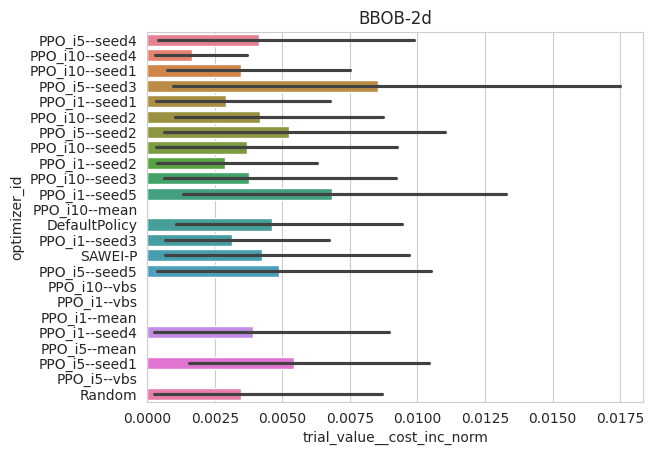

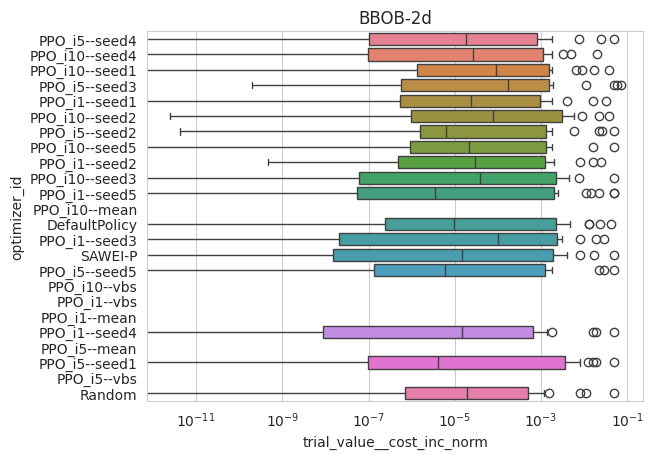

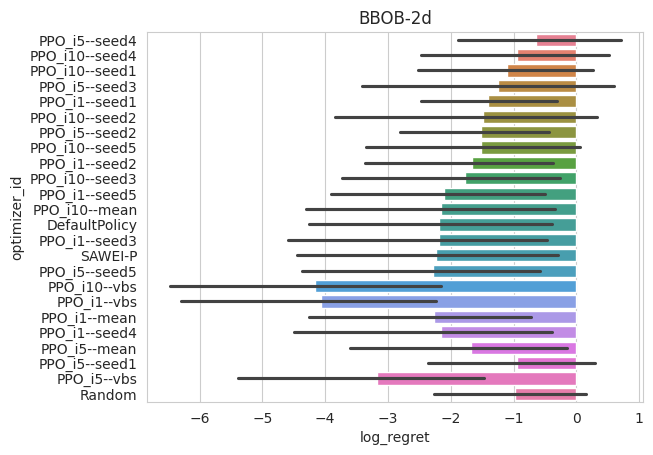

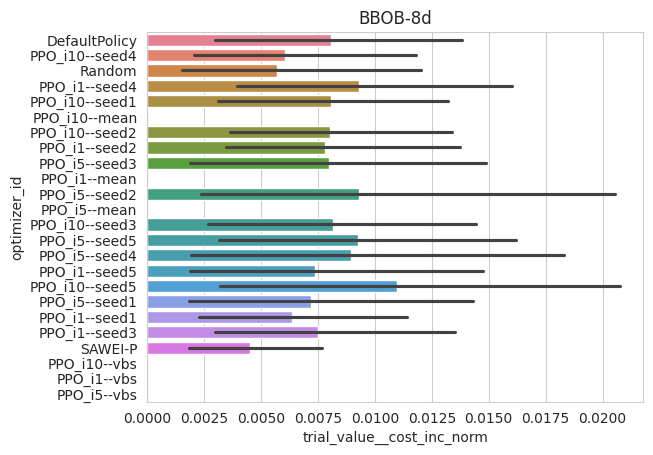

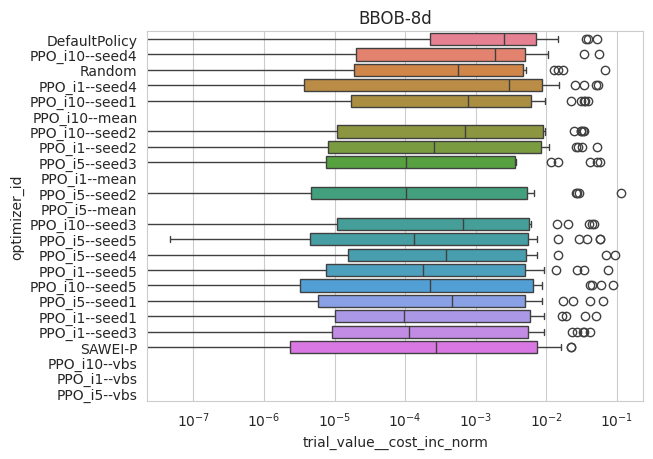

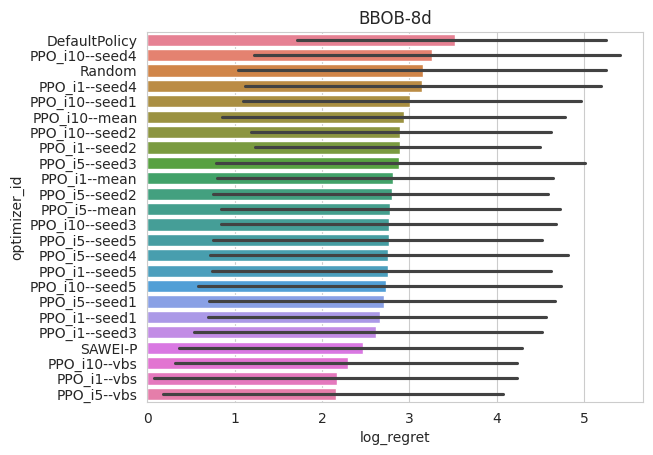

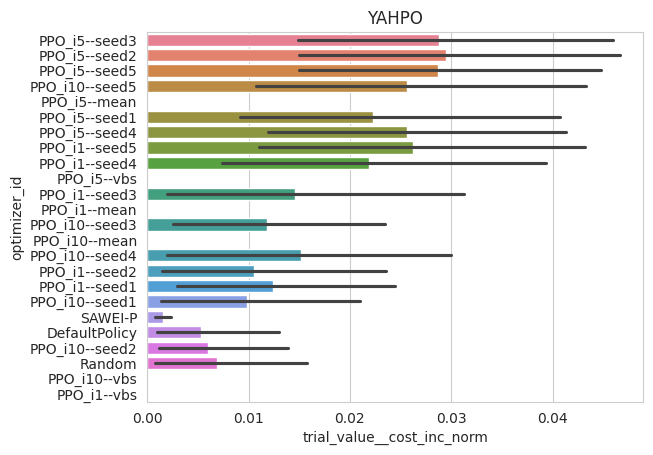

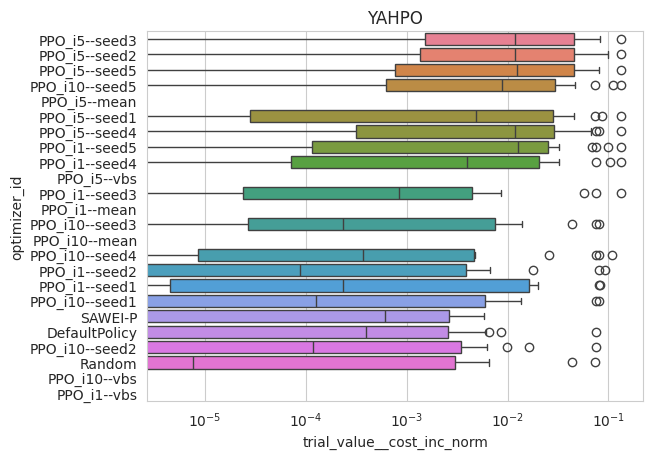

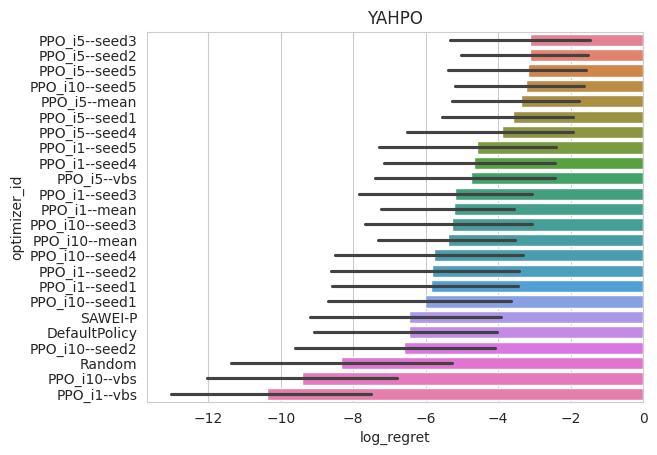

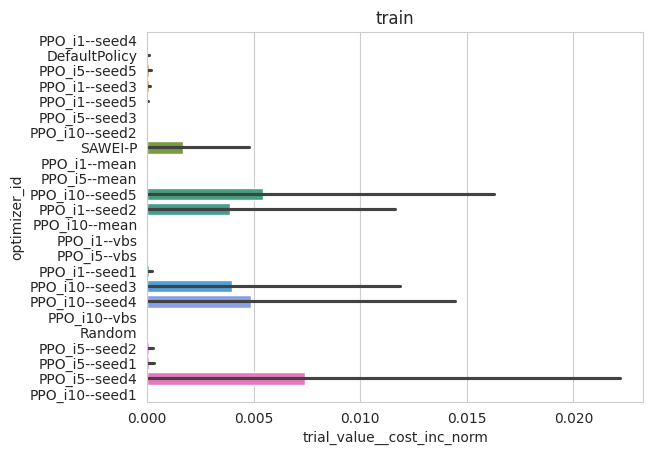

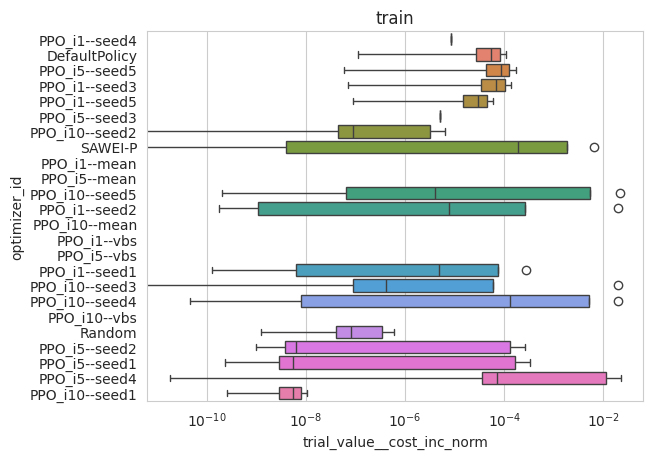

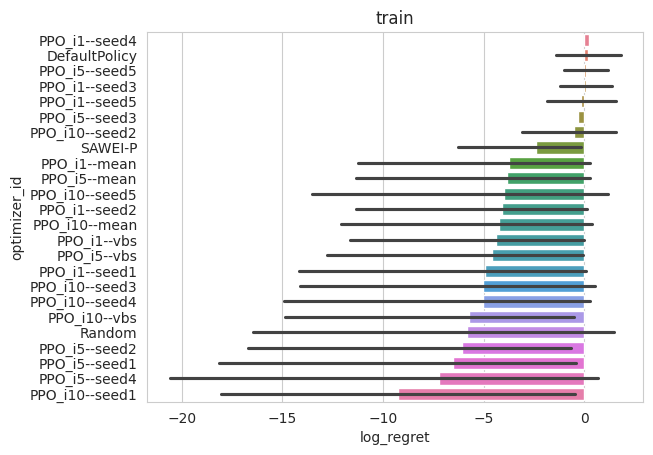

In [29]:
for benchmark_id, gdf in df_final.groupby("benchmark_id"):
    gdf = sort_df_by_mean(gdf, key_performance="log_regret")
    ax = sns.barplot(data=gdf, x="trial_value__cost_inc_norm", y="optimizer_id", hue="optimizer_id")
    ax.set_title(benchmark_id)
    # ax.set_xscale("log")
    plt.show()
    ax = sns.boxplot(data=gdf, x="trial_value__cost_inc_norm", y="optimizer_id", hue="optimizer_id")
    ax.set_xscale("log")
    ax.set_title(benchmark_id)
    plt.show()
    ax = sns.barplot(data=gdf, x="log_regret", y="optimizer_id", hue="optimizer_id")
    ax.set_title(benchmark_id)
    # ax.set_xscale("log")
    plt.show()

/bigwork/nhwpbenc/repos/dacboenv/.env/lib/python3.13/site-packages/pandas/core/groupby/ops.py:928: RuntimeWarning: Mean of empty slice
  res = f(group)


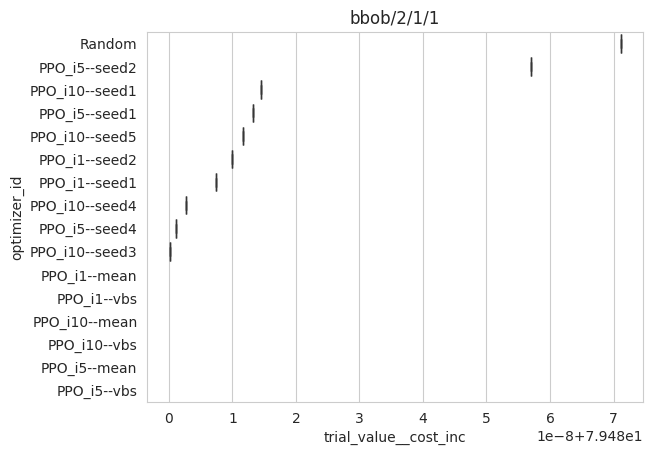

/bigwork/nhwpbenc/repos/dacboenv/.env/lib/python3.13/site-packages/pandas/core/groupby/ops.py:928: RuntimeWarning: Mean of empty slice
  res = f(group)


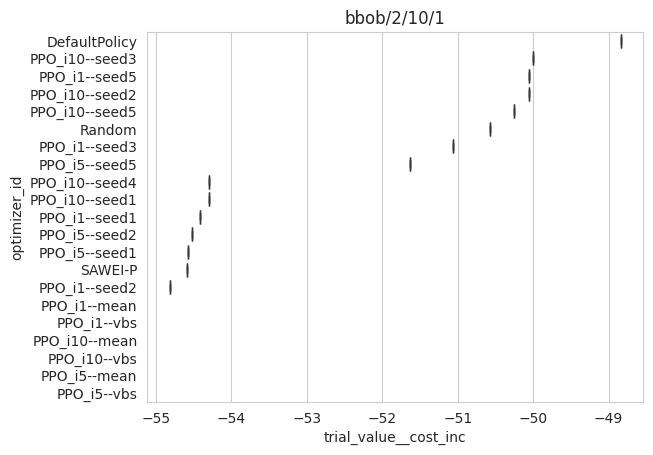

/bigwork/nhwpbenc/repos/dacboenv/.env/lib/python3.13/site-packages/pandas/core/groupby/ops.py:928: RuntimeWarning: Mean of empty slice
  res = f(group)


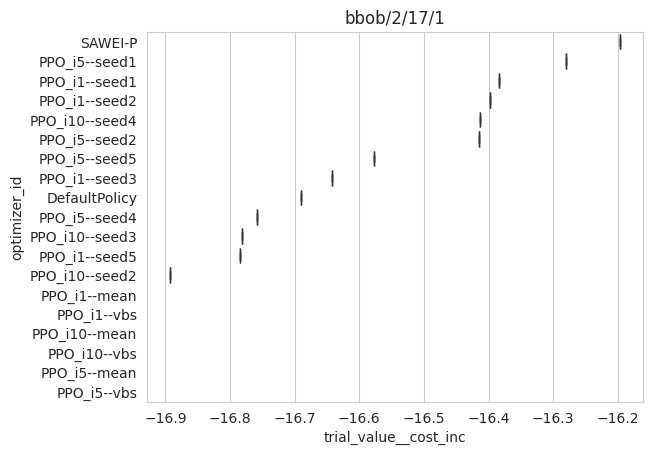

/bigwork/nhwpbenc/repos/dacboenv/.env/lib/python3.13/site-packages/pandas/core/groupby/ops.py:928: RuntimeWarning: Mean of empty slice
  res = f(group)


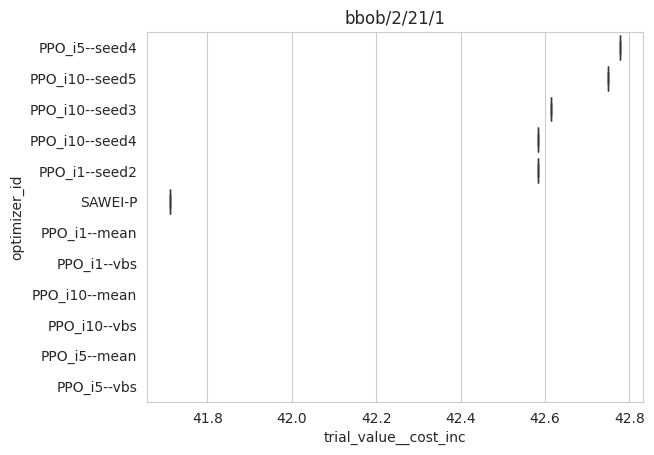

/bigwork/nhwpbenc/repos/dacboenv/.env/lib/python3.13/site-packages/pandas/core/groupby/ops.py:928: RuntimeWarning: Mean of empty slice
  res = f(group)


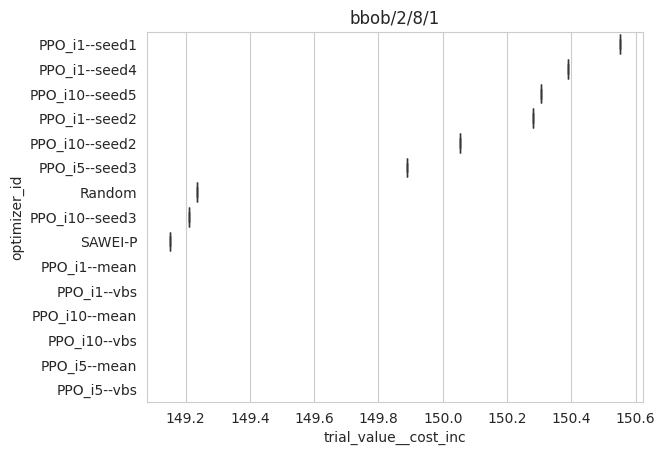

In [33]:
df_final_train = df_final[df_final["benchmark_id"] == "train"]

for task_id, gdf in df_final_train.groupby("task_id"):
    gdf = sort_df_by_mean(gdf, key_performance="trial_value__cost_inc")
    ax = sns.boxplot(data=gdf, x="trial_value__cost_inc", y="optimizer_id")
    ax.set_title(task_id)
    plt.show()

# grid  = sns.FacetGrid(data=df_final_train, col="task_id", col_wrap=4, sharex=False)
# grid.map_dataframe(sns.boxplot, x="trial_value__cost_inc", y="optimizer_id")
# grid.add_legend()
# plt.show()